# Close evaluation of the scattered field for a sound-hard sphere

Plane wave $u^{\text{inc}} = e^{ikz}$ scattered by the sound-hard unit sphere.
The trace $u$ of the scattered field solves the BIE
$(\tfrac12 I - \mathcal D)\,u = \mathcal S[\partial_n u^{\text{inc}}]$
(solved in `sound_hard_bie.Compute_data`), and the field is recovered from
$u(x) = \mathcal D[u](x) + \mathcal S[\partial_n u^{\text{inc}}](x)$.

For evaluation points $x = y^* + \epsilon\,\nu^*$ close to the boundary the layer
potentials are nearly singular.  We compare

* **PGQ** — plain product Gauss quadrature of the representation formula, and
* **subtraction** — the close-evaluation method of Carvalho, Khatri & Kim:
  the quadrature grid is rotated so that its north pole is at $y^*$, and the plane wave
  $u^*(y)\,e^{-ik\nu^*\cdot(x-y)}$ (an exact Helmholtz solution matching $u$ at $y^*$)
  is subtracted, its contribution being restored analytically via Green's identity:
  $\mathcal D[u^* e^{-ik\nu^*\cdot(x-\cdot)}](x) = \mathcal S[ik\,\nu\!\cdot\!\nu^*\,u^* e^{-ik\nu^*\cdot(x-\cdot)}](x)$.

The subtraction method should show an error $O(\epsilon)$ (slope 1) down to the
quadrature floor, whereas PGQ stalls at $O(1)$ as $\epsilon \to 0$.

In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

from essentials_bie import (GaussLegendre, ComputeSphericalHarmonics, ComputeSurface,
                            ComputeIncidentFunction, ComputeExpansionFunction, h1n)
from sound_hard_bie import Compute_data

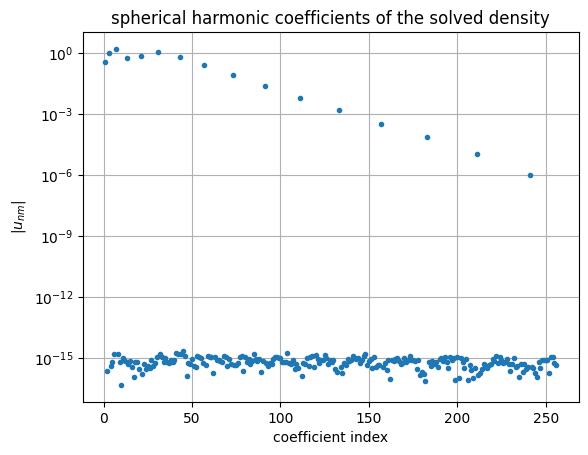

In [2]:
kw = 5.0        # wavenumber
N = 16          # quadrature / expansion order (N**2 spherical harmonics)
M = 2 * N

# solve the Galerkin BIE for the trace of the scattered field
u_nm = Compute_data(N, kw)

plt.figure()
plt.semilogy(np.arange(1, N**2 + 1), np.abs(u_nm), '.')
plt.xlabel('coefficient index'); plt.ylabel('$|u_{nm}|$')
plt.title('spherical harmonic coefficients of the solved density')
plt.grid(True)

In [3]:
# quadrature rules
mu, _, _, _, _, ws = GaussLegendre(N)
wt = ws / (np.pi / 2)                    # plain Gauss-Legendre weights
t = np.arange(-np.pi, np.pi, np.pi / N)

s = 0.5 * np.pi * (mu + 1)               # subtraction method: linear map, sin(s) Jacobian
S, T = np.repeat(s, M), np.tile(t, N)
s2 = np.arccos(mu)                        # PGQ: theta = arccos(mu), weights wt
S2, T2 = np.repeat(s2, M), np.tile(t, N)

# target boundary point y* and its outward normal
theta0, phi0 = s[1], t[1]
_, _, ystar, nustar, _ = ComputeSurface(0, 0, theta0, phi0)
ystar, nustar = ystar.flatten(), nustar.flatten()

# integration grids rotated so that the north pole s=0 sits at (theta0, phi0)
th,  ph,  y,  nu,  J  = ComputeSurface(theta0, phi0, S,  T)
th2, ph2, y2, nu2, J2 = ComputeSurface(theta0, phi0, S2, T2)

# density on both grids and at y*
Ynm,  _, _ = ComputeSphericalHarmonics(N, th,  ph)
Ynm2, _, _ = ComputeSphericalHarmonics(N, th2, ph2)
Ynms, _, _ = ComputeSphericalHarmonics(N, np.atleast_1d(theta0), np.atleast_1d(phi0))
u, u2, ustar = Ynm @ u_nm, Ynm2 @ u_nm, (Ynms @ u_nm)[0]

# Neumann data on both grids
f  = ComputeIncidentFunction(y[:, 0],  y[:, 1],  y[:, 2],  kw)
f2 = ComputeIncidentFunction(y2[:, 0], y2[:, 1], y2[:, 2], kw)
dfn, dfn2 = 1j * kw * nu[:, 2] * f, 1j * kw * nu2[:, 2] * f2

def average_t(vals):        # trapezoid average over t (fast index)
    return np.sum(vals.reshape(N, M), axis=1) / M

# exact solution: Mie series, well beyond the density truncation
NEX = N + 30
n = np.arange(NEX)
e_coeff = ComputeExpansionFunction(0, 0, 0, kw, NEX)          # Y_n^0 coefficients
Yn0 = np.sqrt((2 * n + 1) / (4 * np.pi)) * sp.eval_legendre(n, np.cos(theta0))

epsilon = np.array([1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])
error0, error1 = np.zeros(len(epsilon)), np.zeros(len(epsilon))

for i, eps in enumerate(epsilon):
    x = ystar + eps * nustar
    dist = np.linalg.norm(x)
    exact = np.sum(e_coeff * h1n(kw, dist, n) * Yn0)

    # --- PGQ: plain quadrature of D[u] + S[dfn] ---
    yd2 = x - y2
    r2 = np.linalg.norm(yd2, axis=1)
    G2 = 0.5 * J2 * np.exp(1j * kw * r2) / r2
    D2 = ((1 / r2 - 1j * kw) * np.sum(nu2 * yd2, axis=1) / r2) * G2
    approx0 = wt @ average_t(D2 * u2 + G2 * dfn2)

    # --- subtraction method ---
    yd = x - y
    r = np.linalg.norm(yd, axis=1)
    G = 0.5 * J * np.exp(1j * kw * r) / r * np.sin(S)
    D = ((1 / r - 1j * kw) * np.sum(nu * yd, axis=1) / r) * G
    PW = ustar * np.exp(-1j * kw * (yd @ nustar))
    approx1 = ws @ (average_t(D * (u - PW)) +
                    average_t(G * (1j * kw * (nu @ nustar) * PW + dfn)))

    error0[i] = np.abs(exact - approx0)
    error1[i] = np.abs(exact - approx1)

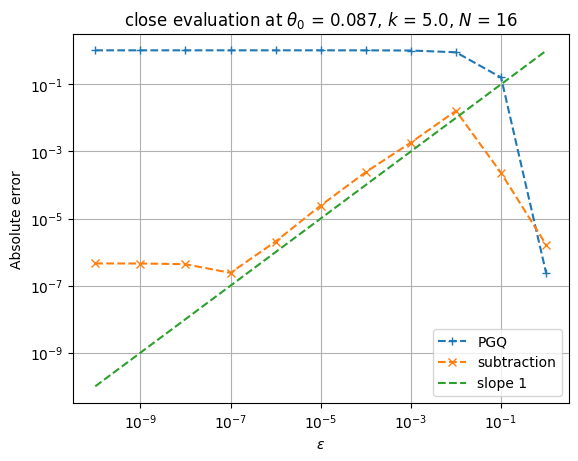

In [4]:
plt.figure()
plt.loglog(epsilon, error0, '--+', label='PGQ')
plt.loglog(epsilon, error1, '--x', label='subtraction')
plt.loglog(epsilon, epsilon, '--', label='slope 1')
plt.xlabel('$\\epsilon$'); plt.ylabel('Absolute error')
plt.title(f'close evaluation at $\\theta_0$ = {theta0:.3f}, $k$ = {kw}, $N$ = {N}')
plt.legend(loc='best'); plt.grid(True)
#plt.savefig(f'helmholtz_Kw_{kw}_N_{N}.png')